# **Tutorial 1** $\cdot$ Feature Attribution Methods

> **Abstract.** This tutorial introduces *feature-attribution methods* for explaining machine learning predictions in molecular property prediction. Feature-attribution methods assign importance scores to abstract molecular descriptors or fingerprint bits, revealing which computed properties most influence a model's predictions. We demonstrate two complementary approaches: (1) **SHAP** (SHapley Additive exPlanations), a game-theoretic method that provides globally consistent attributions by computing each feature's contribution to the prediction relative to a baseline; and (2) **LIME** (Local Interpretable Model-agnostic Explanations), a perturbation-based method that learns local linear surrogate models to explain individual predictions. For SHAP, we use continuous molecular descriptors (ClogP, molecular weight, hydrogen bond donors/acceptors, etc.) with a simple feedforward neural network. For LIME, we use Morgan fingerprints with a deeper network optimized for sparse binary inputs, enabling visualization of the molecular substructures corresponding to important fingerprint bits. Using the AqSolDB water solubility dataset as a case study, we train models, generate explanations with each method, and interpret the results through bar plots, beeswarm plots, and molecular fragment visualizations. The tutorial highlights how both methods identify chemically meaningful features (such as lipophilicity and polar surface area) while offering different perspectives &mdash; SHAP providing global feature importance rankings and LIME revealing instance-specific attributions.


**💾 Dataset.** This notebook will make use of the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) 
dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1). It's a curated dataset consisting of roughly ten thousand 
small molecules annotated with experimentally determined [water solubility](https://en.wikipedia.org/wiki/Solubility) values, reported as **logS** &mdash; the base-10 logarithm of the molar aqueous solubility, so the values are typically negative (the more negative, the less soluble the compound). These target annotations were curated and consolidated from 
various sources throughout the literature. Due to its experimental nature and the presence of measurement noise, it is important to note that 
it is impossible to achieve perfect prediction accuracy for this dataset. Based on results from the literature, the practical limit to the 
performance likely is a predictivity (R² score) in the range between 0.86 and 0.89.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and the calculation of molecular descriptors and fingerprints.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [PyTorch](https://docs.pytorch.org/docs/stable/index.html) and [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of simple neural network models based on the molecular representations.
- [shap](https://github.com/shap/shap) for the calculation and the plotting of the attributional explanations.
- [Captum](https://captum.ai/) for LIME explanations on PyTorch models.

In [2]:
import os
import random

import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rdkit.Chem as Chem
import rdkit.Chem.Crippen
import rdkit.Chem.Descriptors
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import Subset

from xai_chem_review import load_dataset_aqsoldb

# --- reproducibility ---
# A single global seed, reused across every source of randomness in this notebook
# (train/test split, SHAP background sampling, LIME perturbation sampling, weight init).
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
_ = pl.seed_everything(SEED, workers=True)

Seed set to 42


The `load_dataset_aqsoldb` function loads and returns the dataset &mdash; currently stored as a CSV file &mdash; into a pandas `DataFrame` object. In its base form, the dataset represents each molecule as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string. To calculate the molecular descriptors and fingerprint representations for these compounds, however, we need some kind of molecular graph representation. For this purpose we convert each SMILES string into an RDKit `Mol` object and add these as a separate row to the data frame.

In [3]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
data_frame.head()

Loaded dataset with 11024 rows


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [4]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not removing hydrogen atom without neighbors
[14:48:22] WARNING: not r

[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23] WARNING: not removing hydrogen atom without neighbors
[14:48:23

After mol conversion 11022 rows remaining


## **1.1** $\cdot$ 💡 Attributional Explanations

This section will motivate and introduce the concept of attributional explanations in general before jumping into the concrete example explanations.

In explainable AI (xAI), an *explanation* is supposed to add additional, human-interpretable information to the prediction of a complex machine-learning model. In the case of *attributional explanations*, this additional information is presented by revealing how much importance is attributed to different parts of the given input data structure. In other words, these explanations reveal how the model prioritizes different aspects of the input data in its decisions. Among all the information that is passed to the model, certain aspects will be more important than others. In the classic example of credit score prediction, a model will likely have learned to base its prediction on the monthly income rather than the eye color of the applicant. The purpose of attributional explanations is exactly to reveal these learned priorities.

In the context of molecular property prediction, one can further differentiate attributional explanations into the two classes of *feature-attribution* methods and *structure-attribution* methods. Structure-attribution methods aim to directly find certain substructures or motifs within the molecular graph structure itself, which are particularly important for the prediction. Feature-attribution methods on the other hand operate on the level of abstract features that can be assigned to certain molecules. In the end, both methods may communicate very similar information but primarily differ in how this information is *presented* and in the kinds of explanation methods with which they can be obtained. As a concrete example, consider a model that predicts water solubility: a *feature-attribution* method might report that the computed *lipophilicity* (logP) descriptor is the single most influential input, whereas a *structure-attribution* method would instead highlight the specific hydrophobic ring system within the molecule that drives the same effect. This tutorial focuses on feature-attribution methods (SHAP and LIME); structure-attribution methods are the subject of the next tutorial.

## **1.2** $\cdot$ 📚 *SHapley Additive ExPlanations* (`SHAP`)

The first example method from the literature was proposed by [Lundberg *et al.*](https://arxiv.org/abs/1705.07874) and has been cited tens of thousands of times. The method of *SHapley Additive exPlanations (SHAP)* leverages the concept of Shapley values from cooperative game theory to calculate how much each feature contributes towards the final prediction outcome. One particular advantage of SHAP is that it is a model-agnostic, post-hoc method. This means that it can be applied to (almost) any kind of machine learning model after it has already been trained, without having to modify the model itself.

**Implementation.** From an implementation perspective, there exists a feature-rich and relatively well-maintained Python package called `shap`. The package implements the core explanation methods for various different use-cases such as text-based, image-based or tabular data. The package also provides several functions which can be used to plot these explanations to present them in a human-interpretable format.

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Shapley Values and Cooperative Game Theory</summary>

The mathematical foundation of SHAP comes from *cooperative game theory*, a branch of economics developed in the mid-20th century. The key concept &mdash; Shapley values &mdash; was introduced by Lloyd Shapley in 1953 (for which he later received the Nobel Prize in Economics).

**The Cooperative Game Setup.** Imagine a group of players who work together to achieve some total payoff. The central question is: *how should the payoff be fairly divided among the players?* A "fair" division should reflect each player's true contribution to the outcome. But measuring contribution is tricky &mdash; a player might be essential in some combinations of players but redundant in others.

**Marginal Contributions.** Shapley's insight was to consider all possible orderings in which players could join a coalition. For each ordering, we calculate the *marginal contribution* of each player &mdash; how much the total payoff increases when that player joins. The Shapley value for a player is then the average of their marginal contributions across all possible orderings.

**From Games to Features.** In the context of machine learning explanations, we can frame prediction as a cooperative game:
- *Players* = input features (e.g., molecular descriptors)
- *Coalition* = a subset of features used for prediction
- *Payoff* = the model's prediction when using only those features

The Shapley value of a feature tells us its average contribution to the prediction across all possible combinations of features.

**Key Properties.** Shapley values satisfy four important axioms that make them uniquely "fair":
1. **Efficiency**: The attributions sum exactly to the difference between the prediction and the baseline (expected) value
2. **Symmetry**: Features that contribute equally receive equal attribution
3. **Null Player**: Features that never change the prediction receive zero attribution
4. **Linearity**: For combined games, attributions combine linearly

These properties are what make SHAP values particularly appealing &mdash; they provide theoretically grounded, consistent attributions rather than ad-hoc importance scores.

</details>

### Molecular Descriptor Generation

In the very first step, we need to generate the molecular descriptors which will serve as the basis of a machine learning model to predict the water solubility. There already exist pre-defined functions to calculate the full descriptor vectors for a molecule right away in several cheminformatics packages, including RDKit. However, in this instance it makes sense to already think about the explanations that we want to generate later - particularly how these explanations will be presented later. To visualize these explanations, some sort of attribution will have to be associated with every descriptor value. For these explanations to be useful each descriptor will have to be identified with a human-readable name and/or description. Therefore, the following custom implementation of the `DescriptorGenerator` class directly associates the various descriptor functions with human-readable names and descriptions.

In [5]:
class DescriptorGenerator:
    """
    A class to generate molecular descriptors for a given molecule.
    """
    
    # This dictionary defines which molecular descriptors will be generated and how they are calculated. The 
    # keys of the dictionary are the names of the descriptors and the corresponding values are again dictionaries
    # which supply the necessary information about that descriptor. For each descriptor the following three 
    # keys are required:
    # - `name`: A human-readable name for the descriptor.
    # - `description`: A human-readable description of the descriptor.
    # - `function`: A callable function that accepts an RDKit `Mol` object and returns a list of float values 
    #   representing the corresponding descriptor values.
    DESCRIPTOR_DETAIL_MAP: dict[str, dict] = {
        'clogp': {
            'name': 'Crippen LogP',
            'description': 'Fragment-based Crippen LogP approximation',
            'function': lambda mol: [Chem.Crippen.MolLogP(mol)],
        },
        'cmr': {
            'name': 'Crippen Molecular Refractivity',
            'description': 'Fragment-based Crippen Molecular Refractivity approximation',
            'function': lambda mol: [Chem.Crippen.MolMR(mol)],
        },
        'weight': {
            'name': 'Molecular Weight',
            'description': 'Molecular weight',
            'function': lambda mol: [Chem.Descriptors.MolWt(mol)],
        },
        'num_aromatic_rings': {
            'name': 'Num. Aromatic Rings',
            'description': 'Number of aromatic rings',
            'function': lambda mol: [Chem.Descriptors.NumAromaticRings(mol)],
        },
        'num_h_donors': {
            'name': 'Num. H-bond Donors',
            'description': 'Number of hydrogen bond donors',
            'function': lambda mol: [Chem.Descriptors.NumHDonors(mol)],
        },
        'num_h_acceptors': {
            'name': 'Num. H-bond Acceptors',
            'description': 'Number of hydrogen bond acceptors',
            'function': lambda mol: [Chem.Descriptors.NumHAcceptors(mol)],
        },
        'num_rotatable_bonds': {
            'name': 'Num. Rotatable Bonds',
            'description': 'Number of rotatable bonds',
            'function': lambda mol: [Chem.Descriptors.NumRotatableBonds(mol)],
        },
        'num_valence_electrons': {
            'name': 'Valence Electron Count',
            'description': 'Number of valence electrons',
            'function': lambda mol: [Chem.Descriptors.NumValenceElectrons(mol)],
        },
        'num_halogen_frags': {
            'name': 'Num. Halogen Fragments',
            'description': 'Number of halogen fragments',
            'function': lambda mol: [Chem.Descriptors.fr_halogen(mol)],
        }
    }
    
    def get_descriptor_vector(self, value: str | Chem.Mol) -> list[float]:
        """
        Given the RDKit.Mol object `value`, this method returns a list of float values representing 
        the molecular descriptor vector as it is defined by the `self.DESCRIPTOR_DETAIL_MAP` 
        dictionary structure.
        
        :param value: Either a SMILES string or an RDKit.Mol object representing the molecule for which
            for which the descriptor vector should be calculated.
            
        :return: A list of float values representing the molecular descriptor vector.
        """
        
        # We'll accept the input argument as either a SMILES string representation, which we first 
        # need to convert to a mol object, or a mol object directly.
        if isinstance(value, str):
            mol: Chem.Mol = Chem.MolFromSmiles(value)
        else:
            mol: Chem.Mol = value
        
        # This list will contain all of the actually calculated descriptor values and is converted 
        # into a numpy array at the end.
        values: list[float] = []
        # Using the Mol object, we can generate the descriptor vector by iteratively applying all 
        # of the descriptor-producing functions defined in the DESCRIPTOR_DETAIL_MAP
        for descriptor_name, descriptor_info in self.DESCRIPTOR_DETAIL_MAP.items():
            values += descriptor_info['function'](mol)
            
        return values
    
    # --- properties ---
    
    @property
    def descriptor_names(self) -> list[str]:
        """
        A list of all the human-readable descriptor names in the same order as the actual values in the 
        descriptor vectors calculated by this class.
        """
        descriptor_names: list[str] = [
            descriptor_info['name']
            for descriptor_key, descriptor_info in self.DESCRIPTOR_DETAIL_MAP.items()
        ]
        return descriptor_names
    
    def __len__(self) -> int:
        """
        Returns the number of descriptors generated by this generator for each molecule.
        """
        return len(self.DESCRIPTOR_DETAIL_MAP)
        
        
# --- example usage ---

smiles: str = 'Cc1cccc(C=C)c1'
print('Generating example descriptor vector for SMILES: ', smiles)

descriptor_generator = DescriptorGenerator()
descriptors: np.ndarray = descriptor_generator.get_descriptor_vector(smiles)
pprint(descriptors)


Generating example descriptor vector for SMILES:  Cc1cccc(C=C)c1


[2.638020000000001, 41.27000000000002, 118.17899999999999, 1, 0, 0, 1, 46, 0]

Using the instance of the `DescriptorGenerator` class we can now convert all the Mol objects of the dataset into their corresponding descriptor vector representations and add them as an additional column of the data frame.

In [6]:
# --- generating descriptors for dataset ---

data_frame['descriptors'] = data_frame['mol'].apply(descriptor_generator.get_descriptor_vector)
data_frame[['smiles', 'descriptors', 'solubility']].head()

,smiles,descriptors,solubility
0,Cc1cccc(C=C)c1,"[2.638020000000001, 41.27000000000002, 118.178...",-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,"[4.657380000000004, 87.28960000000004, 284.399...",-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,"[3.850900000000003, 72.56500000000005, 256.385...",-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,"[7.903900000000008, 94.38400000000009, 282.556...",-6.451105
4,NC(=O)N=NC(N)=O,"[-0.40399999999999986, 24.022800000000007, 116...",-3.546243


<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.1** $\cdot$ Add the [Topological Polar Surface Area (TPSA)](https://en.wikipedia.org/wiki/Polar_surface_area) as an additional value in the vector of descriptors.

</div>

### Model Training

As a next step we want to train a simple neural network model to predict the water solubility based on the descriptor vector that we've just defined. To train the network, we'll be using the [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) library. In order to do so, however, the dataset needs to be processed into a PyTorch-compatible format. More specifically, PyTorch Lightning expects the data to be packaged into `DataLoader` instances. These data loader objects automatically handle the shuffling and batching of the data during training. One such data loader itself can be created from a PyTorch `TensorDataset`.

In addition to this conversion, it also makes sense to split the available data into a disjoint *train* and a *test* set to evaluate the model performance later on.

In [7]:
# --- train-test split ---
indices = range(len(data_frame))
test_indices = random.sample(indices, k=int(len(data_frame) * 0.2))
train_indices = list(set(indices) - set(test_indices))

# --- creating tensor dataset ---
# We first need to convert the dataset into `torch.Tensor` objects for the input descriptor vectors and the target values separately.
# We can then use both of the resulting vectors to create a `TensorDataset` object for the entire dataset as a whole.

xs: torch.Tensor = torch.tensor(data_frame['descriptors'].to_list(), dtype=torch.float32)
ys: torch.Tensor = torch.tensor(data_frame['solubility'].to_list(), dtype=torch.float32)

dataset = TensorDataset(xs, ys)

# --- creating dataloaders ---

# Using the whole dataset and the previously split train and test indices, the Subset class can be used to select only a subset of 
# the dataset for further processing.
dataset_train = Subset(dataset, train_indices)
dataset_test = Subset(dataset, test_indices)

# Finally, we can create the `DataLoader` objects from both of these subset instances. Since these data loaders automatically handle the 
# shuffling and batching of the data during training, they need to receive the batch size as a constructor argument.
# The `num_workers` argument specifies how many subprocesses to use for data loading. Together with a reasonable `prefetch_factor`, this 
# ensures that the data is loaded efficiently during training - preventing performance bottlenecks.
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=4, prefetch_factor=2)
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)

In [8]:
from torchmetrics.functional import r2_score

# --- densely connected neural network model ---

class SimpleModel(pl.LightningModule):
    """
    Simple multi-layer densely connected neural network model for the regression of continuous target values 
    based on fixed-length input vector representations.
    
    :param input_dim: The number of input features (length of the descriptor vector).
    :param output_dim: The number of output features (as many as there are target values to predict)
    """
    
    def __init__(self, 
                 input_dim: int, 
                 output_dim: int
                 ) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        # Defining the neural network structure
        self.model = torch.nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Model forward pass based on the batched input tensor `x`.
        
        :param x: Input tensor of shape (batch_size, input_dim)
        
        :returns: The model prediction tensor of shape (batch_size, output_dim)
        """
        return self.model(x)
    
    def training_step(self, 
                      batch: tuple[torch.Tensor, torch.Tensor], 
                      batch_idx: int
                      ) -> torch.Tensor:
        """
        Implementation of the training step. Receives each training `batch` as a tuple of the input tensor `x` and 
        the corresponding ground truth target values `y`.
        Defines the loss function as the mean squared error (MSE) between the true values and the model prediction 
        and returns the resulting loss value.
        """
        
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)

        # Calculate R^2 score using torchmetrics
        r2 = r2_score(y_hat.squeeze(), y)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True)
        
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)
    

# --- instantiating the model ---
    
model = SimpleModel(
    # We can use the length attribute of the descriptor generator to figure out how many features / descriptors
    # were generated for each molecule.
    input_dim=len(descriptor_generator),
    # We want to predict the single solubility value for each molecule.
    output_dim=1,
)

print('--- Testing the model ---')
x_example = torch.tensor(np.random.rand(10, len(descriptor_generator)), dtype=torch.float32)  # 10 vectors
y_example = model(x_example)
print(f'Example predictions for random input vectors (shape: {y_example.shape}):', y_example)


--- Testing the model ---
Example predictions for random input vectors (shape: torch.Size([10, 1])): tensor([[ 0.3519],
        [-0.3854],
        [-0.0987],
        [-0.6372],
        [ 0.2494],
        [-0.4458],
        [ 0.0099],
        [ 0.1461],
        [ 0.1306],
        [-0.1059]], grad_fn=<AddmmBackward0>)


In [9]:
# --- model training ---

trainer = pl.Trainer(
    # number of epochs
    # For simple models and small datasets like this, 25 epochs should be sufficient to converge reasonably well.
    max_epochs=25,
    # If a GPU is available, use it for the training. Otherwise, use the CPU.
    accelerator='auto',
)

# This method will actually start the training process.
trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# This puts the model into evaluation mode. In this case that primarily means that the
# BatchNorm layers use their accumulated running statistics rather than per-batch statistics.
model.eval()

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /media/ssd2/Programming/xai_chem_review/.venv/lib/p ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │ 19.7 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 19.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=25` reached.


SimpleModel(
  (model): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [10]:
# --- evaluate the trained model on the held-out test set ---
# Collect predictions and ground-truth targets across the entire test set, then report
# the coefficient of determination (R²) and the root-mean-square error (RMSE) in logS units.
preds, targets = [], []
model.eval()
with torch.no_grad():
    for x, y in loader_test:
        preds.append(model(x).squeeze())
        targets.append(y)

preds = torch.cat(preds)
targets = torch.cat(targets)

test_rmse = torch.sqrt(torch.mean((preds - targets) ** 2)).item()
test_r2 = r2_score(preds, targets).item()
print(f'Held-out test set ({len(targets)} molecules):  R² = {test_r2:.3f}   RMSE = {test_rmse:.3f} logS')

Held-out test set (2204 molecules):  R² = 0.640   RMSE = 1.379 logS


**📈 Model performance.** The cell above evaluates the trained model on the held-out *test* set &mdash; molecules the network never saw during training. We report two complementary metrics: the coefficient of determination (R², where 1.0 is a perfect fit and 0.0 corresponds to always predicting the mean) and the root-mean-square error (RMSE) expressed in logS units.

**⚠️ Caveat.** This is a deliberately small model trained only briefly (25 epochs, no hyperparameter tuning, and with unnormalized descriptor inputs) so that the tutorial stays fast and self-contained. Its predictivity will therefore fall short of the ~0.86&ndash;0.89 R² that carefully tuned models reach on AqSolDB (see the abstract). Keep this in mind for the explanations that follow: the attribution methods are illustrated *correctly*, but the specific chemical conclusions drawn from them are only as reliable as the underlying model &mdash; treat them as illustrative rather than definitive.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.2** $\cdot$ Change loss function of the model into a [Huber Loss](https://en.wikipedia.org/wiki/Huber_loss) and re-train the network.

</div>

### Generating Explanations

The `shap` package allows us to generate explanations in the form of *SHAP values* based on an arbitrary pre-trained models. For this purpose, the model provides various different `Explainer` classes. For our case of a deep neural network model and tabular data we'll have to use the `DeepExplainer` class, which receives the model as an input as well as a tensor of so called *background data*. This background data is usually chosen as (a subset of) the training data, while the explanations itself are generated on the test data. The purpose of this "background" data is to provide a reference distribution for the various input features. Internally, `DeepExplainer` estimates each feature's contribution by comparing the model's output to its output on these background reference samples: it propagates the background samples through the network (a DeepLIFT-style approximation) and averages over them. The background data therefore defines the baseline (expected) value against which each feature's contribution is measured &mdash; it does *not* simply replace excluded features with a single mean value.

After constructing the explainer instance, the SHAP values can be calculated by supplying a tensor of input features to the `shap_values` method. These SHAP values, along with other additional information, can be used to construct an `Explanation` instance. This explanation object instance is used later on to directly provide all of the necessary information to all of the plotting functions of the package.

**📝 Note.** The model that is supplied to the constructor of the `DeepExplainer` class is supposed to be a *callable* which accepts the input features as a single argument and returns the corresponding prediction. In the case of a PyTorch Lightning `LightningModel` this is possible because the magic method `__call__` is implemented to use the `forward` method. Alternatively, it would be possible to define a new function `predict` which internally queries a pre-trained model and returns the corresponding prediction, if the model itself doesn't implement this.

**📝 Note.** A peculiarity of the `shap` package is that when working with a PyTorch model of any kind it is important to supply any kind of inputs (background data, test data) as a PyTorch `Tensor` instance. When working with a TensorFlow model, for instance, the inputs would have to be supplied as numpy arrays.

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Choosing Background Data for SHAP Explanations</summary>

When setting up the SHAP `DeepExplainer`, we must provide "background data" &mdash; but why is this necessary, and how does the choice affect the resulting explanations?

**Why Background Data?** SHAP explanations measure how each feature contributes to pushing the prediction away from some baseline. But what should this baseline be? In tabular data, we cannot simply "remove" a feature like we might mask a patch in an image. Instead, SHAP simulates feature absence by replacing feature values with values drawn from the background dataset. The background data thus defines what "missing" or "default" feature values look like.

**How It Affects Explanations.** The SHAP value for a feature represents its contribution relative to the expected prediction over the background distribution. Different backgrounds lead to different baselines and thus different attributions:

- If the background consists of mostly *low* molecular weight compounds, then a high molecular weight in a test molecule will result in a large positive SHAP value for that feature
- If the background consists of mostly *high* molecular weight compounds, the same test molecule might show a negative SHAP value

The explanations essentially answer the question: "How does this molecule differ from a *typical* molecule in the background set?"

**Common Strategies:**

1. **Random Training Subset** (used in this tutorial): Simple and often effective. We select 100-1000 random samples from the training data to represent the "typical" input the model sees.

2. **K-Means Representatives**: We can cluster the training data and use cluster centroids as background. This approach better captures the diversity of the data with fewer samples, improving computational efficiency.

3. **Domain-Specific Baseline**: In some applications, a meaningful reference point exists. For molecular solubility, one might use a set of "neutral" molecules with average properties.

4. **Single-Value Baseline**: Using a single reference point (e.g., all zeros, or the training mean) is computationally cheapest but may not represent realistic feature combinations.

**Practical Considerations:**

- At least 100-1000 background samples are recommended for stable explanations
- The background distribution should be representative of the training data
- Very small backgrounds can lead to high-variance, unstable explanations
- When comparing explanations across studies, it is important to document the background selection carefully

</details>

In [11]:
# --- setting up the explainer ---

# Selecting 1000 samples from the dataset to use as background data for SHAP to calculate summary 
# statistics about the distribution of the input features from.
background_indices = random.sample(train_indices, k=1000)
background_tensor = torch.tensor(xs[background_indices].numpy())

explainer = shap.DeepExplainer(
    model=model,
    data=background_tensor,
)

# --- calculating SHAP values ---
test_tensor = torch.tensor(xs[test_indices].numpy())
shap_values = explainer.shap_values(test_tensor)
base_values = np.repeat(np.array(explainer.expected_value), test_tensor.shape[0], axis=0)

# After calculating the SHAP values themselves, we can create an `Explanation` object which bundles all the 
# important information for the plotting functions later on. This includes, for example, the SHAP values
# themselves, the input features from which those were calculated and the human-readable names of these features.
shap_exp: shap.Explanation = shap.Explanation(
    values=np.squeeze(shap_values),
    base_values=base_values,
    data=test_tensor.numpy(),
    feature_names=descriptor_generator.descriptor_names,
)
pprint(shap_exp, max_length=10)

.values =
array([[ 0.91018152,  0.11462698,  0.23995364, ..., -0.1838847 ,
│   │   -0.096634  , -0.08914633],
│      [ 2.53083038, -0.11547339, -0.51699042, ...,  0.06866157,
│   │    0.0392197 , -0.02000081],
│      [ 0.09644027, -0.49717754,  2.68726921, ..., -0.18816896,
│   │   -1.03172338, -0.14019501],
│      ...,
│      [ 1.33672857, -0.46406004,  1.17978311, ..., -0.15877548,
│   │    0.00804166, -0.09517555],
│      [-0.2864612 , -0.30382261, -0.33146036, ...,  0.56955183,
│   │   -0.16003348,  0.03273646],
│      [ 0.59439617, -0.09463073,  1.46828938, ..., -0.16603653,
│   │   -0.41842178, -0.10594437]])

.base_values =
array([-3.1198177, -3.1198177, -3.1198177, ..., -3.1198177, -3.1198177,
│      -3.1198177], dtype=float32)

.data =
array([[ 1.21010e+00,  5.09804e+01,  1.80207e+02, ...,  2.00000e+00,
│   │    7.00000e+01,  0.00000e+00],
│      [-1.42406e+01,  2.92048e+01,  2.58069e+02, ...,  5.00000e+00,
│   │    7.40000e+01,  0.00000e+00],
│      [ 2.30344e+00,  3.59160e+01,  1.06168e+02, ...,  0.00000e+00,
│   │    4.20000e+01,  0.00000e+00],
│      ...,
│      [ 1.01900e-01,  2.90286e+01,  1.30099e+02, ...,  2.00000e+00,
│   │    5.00000e+01,  0.00000e+00],
│      [ 3.03650e+00,  9.46882e+01,  3.64423e+02, ...,  8.00000e+00,
│   │    1.34000e+02,  0.00000e+00],
│      [ 1.66750e+00,  4.20234e+01,  1.37182e+02, ...,  2.00000e+00,
│   │    5.40000e+01,  0.00000e+00]], dtype=float32)

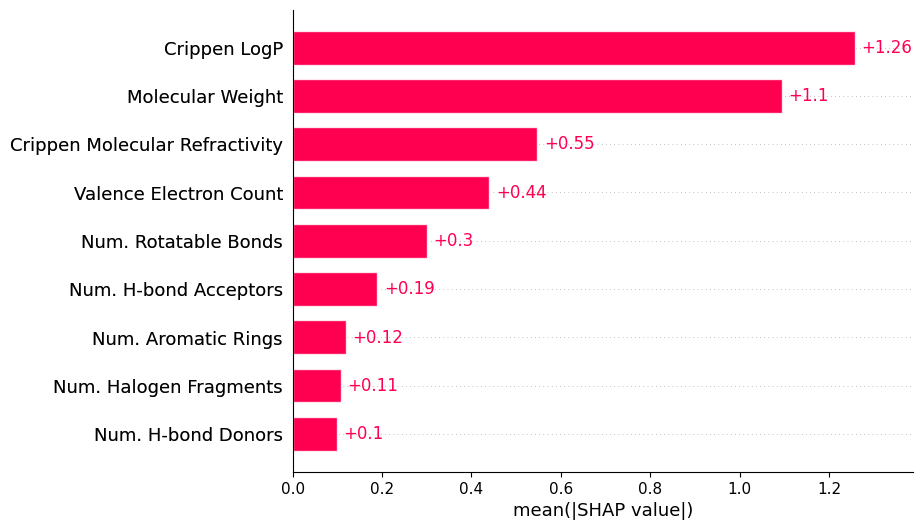

In [29]:
# --- visualizing explanations ---

ax = shap.plots.bar(shap_exp, show=False, max_display=10)

**📊 Feature Importance Plot.** This first plot illustrates the absolute feature importance for the various molecular descriptors. The vertical axis shows the human-readable names of the descriptors that were defined above and the bars along the horizontal axis show the average absolute value of the SHAP values for those features. Generally, a larger bar indicates more important features. An analysis of the absolute importance like this already presents valuable information, but it still misses the information *how* exactly these features are important for the prediction outcome.

The plot should show that Crippen's logP value and the Molecular Weight tend to be among the most important features for predicting the water solubility, while simple counts such as the number of hydrogen-bond donors, aromatic rings, or halogen fragments tend to contribute the least. Note that the precise ranking — especially among the low-importance descriptors — is specific to a given training run and may shift somewhat if the notebook is re-trained.

(-15.0, 15.0)

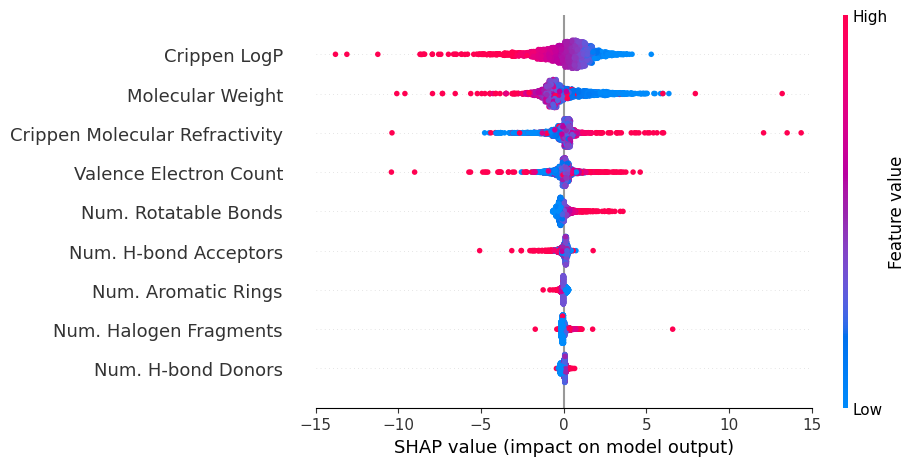

In [30]:
# --- visualizing explanations ---

ax = shap.plots.beeswarm(shap_exp, show=False, group_remaining_features=False)
ax.set_xlim(-15, 15)

**📊 Beeswarm Plot.** Contrary to the previous feature importance bar plot, the beeswarm plot contains additional information to indicate *how* a given feature contributes to the prediction result but is also slightly harder to read. The vertical axis again lists the human-readable name of the various features/descriptors defined above. The horizontal axis indicates the SHAP values which can be interpreted as the strength of the contribution toward the prediction outcome. These SHAP values can be positive and negative — positive values indicating that the feature pushes the prediction toward a higher value (here, a higher predicted logS &mdash; i.e. greater solubility), while negative values suggest the feature pulls the prediction downward.

Each point in the plot corresponds to a single instance in the dataset and is color-coded based on the feature value - typically spanning from low values (blue) to high values (red). Relative to the range of possible values observed within the dataset, a red color represents a particularly high value while a blue color represents a relatively low value. This way, one can simultaneously observe both the direction and magnitude of the effect of a feature on the model’s prediction, as well as how this varies across different samples.

The row representing Crippen's LogP descriptor should provide a particularly illustrative example of this: The left part of the plot (negative SHAP values) primarily consists of red dots, indicating high feature values, while the right part of the plot (positive SHAP values) primarily consists of blue dots, indicating low feature values. Summarizing these findings, according to these explanations, low values of ClogP are indicative of *increased* water solubility while high values of ClogP indicate *decreased* water solubility. These findings reflect the well-known anticorrelation between the octanol–water partition coefficient and the water solubility logS.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.3** $\cdot$ Instead of a two-layer fully connected network, change the model to be a *four*-layer fully connected network with hidden dimensions of your own choosing and re-train the model. What changes do you observe in the explanations?

</div>

## **1.3** $\cdot$ 📚 *Local Interpretable Model-agnostic Explanations* (`LIME`)

The second example method from the literature was proposed by [Ribeiro *et al.*](https://arxiv.org/abs/1602.04938) and provides an alternative approach to generating local explanations. The method of *Local Interpretable Model-agnostic Explanations (LIME)* works by learning a local linear surrogate model around each prediction to explain individual instances. Whereas SHAP values are computed per instance but are commonly aggregated across the dataset to yield a *global* view of feature importance, LIME focuses purely on understanding model behavior in the immediate neighborhood of a single prediction.

**Implementation.** LIME is available through multiple Python packages, but for this tutorial we will use the implementation provided by the `captum` library, which offers optimized implementations specifically designed for PyTorch models. This implementation is particularly well-suited for working with discrete features like molecular fingerprints, where perturbations need to respect the binary nature of the representation.

### Morgan Fingerprint Generation

For LIME explanations, we'll use Morgan fingerprints as molecular representations instead of the continuous-valued descriptors used with SHAP. Morgan fingerprints &mdash; also known as **Extended-Connectivity Fingerprints (ECFP)**; with the radius-2 setting used here they correspond to the commonly cited ECFP4 &mdash; are binary vectors where each **bit** is one position in the fixed-length vector (1024 bits in this tutorial), set to 1 if the corresponding circular substructure is present in the molecule and 0 otherwise. This discrete representation is particularly well-suited for LIME, which works by perturbing input features and observing how predictions change. The binary nature of fingerprints allows for clear on/off perturbations that respect the underlying data structure.

Similar to the descriptor generator, we'll implement a custom `MorganFingerprintGenerator` class that provides both the fingerprint calculation functionality and human-readable feature names for interpretation.

Generating example Morgan fingerprint for SMILES:  Cc1cccc(C=C)c1
Fingerprint length: 1024
Number of set bits: 20
First 20 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Bit info for first few active bits: [(15, ((3, 2),)), (31, ((2, 2),)), (33, ((0, 0),))]

🎨 Modern RDKit bit visualization examples:

📍 Single bit visualization for first active bit (15):


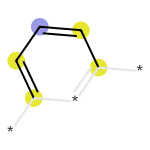


📍 Multiple bits visualization (first 4 active bits):


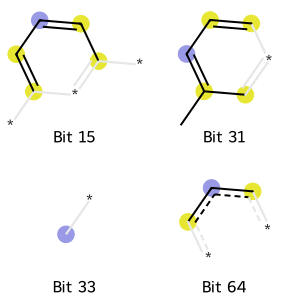

In [31]:
import rdkit.Chem.rdMolDescriptors as rdMolDescriptors
from rdkit import DataStructs
from rdkit.Chem import rdDepictor, Draw
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import SVG, display
import matplotlib.pyplot as plt

class MorganFingerprintGenerator:
    """
    A class to generate Morgan fingerprints for molecules with interpretable bit information.
    """
    
    def __init__(self, radius: int = 2, n_bits: int = 1024):
        """
        Initialize the Morgan fingerprint generator.
        
        :param radius: The radius for the Morgan fingerprint calculation (default: 2)
        :param n_bits: The number of bits in the fingerprint vector (default: 1024)
        """
        self.radius = radius
        self.n_bits = n_bits
        # Initialize the Morgan generator with the specified radius
        self.morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
            radius=radius, 
            fpSize=n_bits,
            countSimulation=False,    
        )
        
    def get_fingerprint_vector(self, value: str | Chem.Mol) -> list[int]:
        """
        Generate a Morgan fingerprint vector for the given molecule.
        
        :param value: Either a SMILES string or an RDKit.Mol object
        :return: A list of integers (0 or 1) representing the fingerprint bits
        """
        if isinstance(value, str):
            mol: Chem.Mol = Chem.MolFromSmiles(value)
        else:
            mol: Chem.Mol = value
            
        if mol is None:
            return [0] * self.n_bits
            
        # Generate Morgan fingerprint as bit vector using the new API
        bit_vect = self.morgan_generator.GetFingerprint(mol)
        
        # Convert to list of integers (0 or 1)
        return [1 if bit_vect[i] > 0 else 0 for i in range(self.n_bits)]
    
    def get_bit_info(self, value: str | Chem.Mol) -> dict:
        """
        Get information about which molecular fragments correspond to which bits.
        
        :param value: Either a SMILES string or an RDKit.Mol object
        :return: Dictionary mapping bit indices to fragment information
        """
        if isinstance(value, str):
            mol: Chem.Mol = Chem.MolFromSmiles(value)
        else:
            mol: Chem.Mol = value
            
        if mol is None:
            return {}
            
        # Set up additional output to capture bit information
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()  # For Morgan fingerprints
        ao.AllocateAtomCounts()  # Optional: atom contribution counts
        ao.AllocateAtomToBits()  # Optional: which bits each atom contributes to
        
        fp = self.morgan_generator.GetFingerprint(mol, additionalOutput=ao)
        
        # Convert the additional output to the expected format
        bit_info = ao.GetBitInfoMap()
        
        return bit_info
    
    def visualize_bit_patterns(self, molecules: list, bit_indices: list[int], max_examples: int = 5) -> None:
        """
        Visualize molecular patterns corresponding to specific fingerprint bits using modern RDKit functionality.

        :param molecules: List of molecules (SMILES strings or Mol objects) to search for patterns
        :param bit_indices: List of bit indices to visualize
        :param max_examples: Maximum number of example molecules to show per bit
        """
        print("🔍 Analyzing fingerprint bit patterns...")
        
        # For each bit, find molecules that have this bit set and visualize the corresponding fragments
        for bit_idx in bit_indices:
            print(f"\n{'='*60}")
            print(f"📍 Bit {bit_idx} - Fragment Analysis")
            print(f"{'='*60}")
            
            examples_found = 0
            bit_examples = []  # Collect examples for batch visualization
            
            for mol_data in molecules:
                if examples_found >= max_examples:
                    break
                    
                # Convert to mol object if needed
                if isinstance(mol_data, str):
                    mol = Chem.MolFromSmiles(mol_data)
                    smiles = mol_data
                elif hasattr(mol_data, 'smiles'):
                    mol = mol_data.mol if hasattr(mol_data, 'mol') else Chem.MolFromSmiles(mol_data.smiles)
                    smiles = mol_data.smiles
                else:
                    mol = mol_data
                    smiles = Chem.MolToSmiles(mol)
                    
                if mol is None:
                    continue
                
                # Get fingerprint and bit info for this molecule
                fingerprint = self.get_fingerprint_vector(mol)
                bit_info = self.get_bit_info(mol)
                
                # Check if this bit is set in this molecule
                if fingerprint[bit_idx] == 1 and bit_idx in bit_info:
                    examples_found += 1
                    print(f"\n🧪 Example {examples_found}: {smiles}")
                    
                    # Store example for batch visualization
                    bit_examples.append((mol, bit_idx, bit_info))
            
            # Use modern RDKit functionality for visualization
            if bit_examples:
                # For single bit visualization of each example
                for i, (mol, bit_id, bit_info) in enumerate(bit_examples, 1):
                    print(f"\n🎨 Visualizing Bit {bit_id} - Example {i}")
                    img = Draw.DrawMorganBit(mol, bit_id, bit_info)
                    display(img)
                
                # For multiple examples at once (if more than one example)
                if len(bit_examples) > 1:
                    print(f"\n🎨 All examples for Bit {bit_idx} together:")
                    labels = [f"Example {i+1}" for i in range(len(bit_examples))]
                    img = Draw.DrawMorganBits(bit_examples[:12], molsPerRow=4, legends=labels[:12])
                    display(img)
            else:
                print("❌ No examples found for this bit in the provided molecules")
                
    @property
    def feature_names(self) -> list[str]:
        """
        Generate feature names for each bit in the fingerprint.

        :return: List of human-readable feature names
        """
        return [f'Morgan_bit_{i}' for i in range(self.n_bits)]
    
    def __len__(self) -> int:
        """
        Returns the number of bits in the fingerprint.
        """
        return self.n_bits

# --- example usage ---

smiles: str = 'Cc1cccc(C=C)c1'
print('Generating example Morgan fingerprint for SMILES: ', smiles)

fingerprint_generator = MorganFingerprintGenerator(radius=2, n_bits=1024)
fingerprint: list[int] = fingerprint_generator.get_fingerprint_vector(smiles)
bit_info = fingerprint_generator.get_bit_info(smiles)

print(f'Fingerprint length: {len(fingerprint)}')
print(f'Number of set bits: {sum(fingerprint)}')
print(f'First 20 bits: {fingerprint[:20]}')
print(f'Bit info for first few active bits: {list(bit_info.items())[:3]}')

# --- Modern RDKit bit visualization example ---
print("\n🎨 Modern RDKit bit visualization examples:")

mol = Chem.MolFromSmiles(smiles)
on_bits = list([i for i, bit in enumerate(fingerprint) if bit == 1][:5])  # Get first 5 set bits

if on_bits:
    print(f"\n📍 Single bit visualization for first active bit ({on_bits[0]}):")
    # For single bit visualization
    first_bit_id = on_bits[0]
    if first_bit_id in bit_info:
        img = Draw.DrawMorganBit(mol, first_bit_id, bit_info)
        display(img)
    
    print(f"\n📍 Multiple bits visualization (first {min(4, len(on_bits))} active bits):")
    # For multiple bits at once
    multi_bit_examples = [(mol, bit_id, bit_info) for bit_id in on_bits[:4] if bit_id in bit_info]
    if multi_bit_examples:
        labels = [f"Bit {bit_id}" for mol, bit_id, bit_info in multi_bit_examples]
        img = Draw.DrawMorganBits(multi_bit_examples, molsPerRow=2, legends=labels)
        display(img)
else:
    print("No active bits found for visualization")

Now we can generate Morgan fingerprints for all molecules in our dataset, similar to how we generated the descriptors earlier:

In [16]:
# --- generating Morgan fingerprints for dataset ---

data_frame['morgan_fingerprints'] = data_frame['mol'].apply(fingerprint_generator.get_fingerprint_vector)
data_frame[['smiles', 'morgan_fingerprints', 'solubility']].head()

,smiles,morgan_fingerprints,solubility
0,Cc1cccc(C=C)c1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-6.451105
4,NC(=O)N=NC(N)=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-3.546243


### Model Training for Morgan Fingerprints

We'll train a new PyTorch Lightning model specifically designed for the binary Morgan fingerprint representation. This model will have a similar architecture to the descriptor-based model but will be optimized for the sparse, high-dimensional binary input vectors.

In [17]:
# --- creating tensor dataset for Morgan fingerprints ---

xs_morgan: torch.Tensor = torch.tensor(data_frame['morgan_fingerprints'].to_list(), dtype=torch.float32)
ys_morgan: torch.Tensor = torch.tensor(data_frame['solubility'].to_list(), dtype=torch.float32)

dataset_morgan = TensorDataset(xs_morgan, ys_morgan)

# --- train-test split for Morgan fingerprints ---
dataset_morgan_train = Subset(dataset_morgan, train_indices)
dataset_morgan_test = Subset(dataset_morgan, test_indices)

loader_morgan_train = DataLoader(dataset_morgan_train, batch_size=32, shuffle=True, num_workers=4, prefetch_factor=2)
loader_morgan_test = DataLoader(dataset_morgan_test, batch_size=32, shuffle=False)

# --- Morgan fingerprint model ---

class MorganFingerprintModel(pl.LightningModule):
    """
    Neural network model optimized for Morgan fingerprint inputs.
    
    :param input_dim: The number of bits in the Morgan fingerprint (should be 1024)
    :param output_dim: The number of output features (1 for regression)
    """
    
    def __init__(self, 
                 input_dim: int, 
                 output_dim: int = 1
                 ) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        # Neural network optimized for sparse binary inputs
        self.model = torch.nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Model forward pass for Morgan fingerprint inputs.
        
        :param x: Input tensor of shape (batch_size, input_dim) with binary values
        :returns: The model prediction tensor of shape (batch_size, output_dim)
        """
        return self.model(x)
    
    def training_step(self, 
                      batch: tuple[torch.Tensor, torch.Tensor], 
                      batch_idx: int
                      ) -> torch.Tensor:
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        y_hat = self.forward(x)
        loss = F.mse_loss(y_hat.squeeze(), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)

        # Calculate R^2 score
        r2 = r2_score(y_hat.squeeze(), y)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True)
        
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)
    

# --- instantiating the Morgan fingerprint model ---
    
morgan_model = MorganFingerprintModel(
    input_dim=len(fingerprint_generator),
    output_dim=1,
)

print('--- Testing the Morgan fingerprint model ---')
x_morgan_example = torch.tensor(np.random.randint(0, 2, (10, len(fingerprint_generator))), dtype=torch.float32)  # 10 binary vectors
y_morgan_example = morgan_model(x_morgan_example)
print(f'Example predictions for random Morgan fingerprints (shape: {y_morgan_example.shape}):', y_morgan_example[:5])

--- Testing the Morgan fingerprint model ---
Example predictions for random Morgan fingerprints (shape: torch.Size([10, 1])): tensor([[ 0.2893],
        [ 0.5224],
        [ 0.5855],
        [-0.1110],
        [-0.1734]], grad_fn=<SliceBackward0>)


In [18]:
# --- Morgan fingerprint model training ---

morgan_trainer = pl.Trainer(
    max_epochs=25,
    accelerator='auto',
)

morgan_trainer.fit(
    model=morgan_model,
    train_dataloaders=loader_morgan_train,
    val_dataloaders=loader_morgan_test,
)

morgan_model.eval()

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /media/ssd2/Programming/xai_chem_review/.venv/lib/p ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  595 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 595 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 595 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=25` reached.


MorganFingerprintModel(
  (model): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=32, bias=True)
    (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

### Generating LIME Explanations

The Captum library provides an efficient implementation of LIME specifically designed for PyTorch models. For binary features like Morgan fingerprints, LIME works by creating perturbed versions of the input where randomly selected bits are turned off (set to 0). It then trains a local linear model to approximate the behavior of the complex neural network in the neighborhood of each specific prediction.

**📝 Note.** Like SHAP, LIME produces a separate attribution for each individual instance; the difference is that SHAP values can be aggregated across the dataset into a consistent *global* importance ranking (as in the SHAP bar plot above), whereas here LIME is used purely locally. The same fingerprint bit might therefore be deemed important for one molecule but not for another, depending on the local context.

**📝 Note.** Because we pass the fingerprints without a `feature_mask`, Captum fits a separate linear surrogate over all 1024 bit-dimensions from `n_samples` perturbations per molecule &mdash; fewer samples than features &mdash; so individual bit attributions are noisy and should be read as rough indications rather than exact importances. Also, only bits that are *on* in a given molecule can be meaningfully perturbed (toggling an already-0 bit changes nothing), so the attributions are informative only for that molecule's active bits.

In [20]:
from captum.attr import Lime

# --- setting up LIME explainer ---

# Create LIME explainer instance
lime_explainer = Lime(morgan_model)

# Select a subset of test samples for explanation
n_samples_explain = 100
explain_indices = random.sample(test_indices, k=min(n_samples_explain, len(test_indices)))
explain_tensor = xs_morgan[explain_indices]
explain_targets = ys_morgan[explain_indices]

print(f"Generating LIME explanations for {len(explain_indices)} samples")

# --- calculating LIME attributions ---

# LIME parameters
n_samples = 1000  # Number of perturbed samples to generate for each explanation

# Generate attributions for the selected samples
lime_attributions = lime_explainer.attribute(
    explain_tensor,
    n_samples=n_samples,
    perturbations_per_eval=16,
    show_progress=False
)

print(f"Generated LIME attributions with shape: {lime_attributions.shape}")
print(f"Attribution value range: [{lime_attributions.min():.4f}, {lime_attributions.max():.4f}]")

Generating LIME explanations for 100 samples


/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/captum/attr/_core/lime.py:1156: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(


Generated LIME attributions with shape: torch.Size([100, 1024])
Attribution value range: [-2.4490, 2.5699]


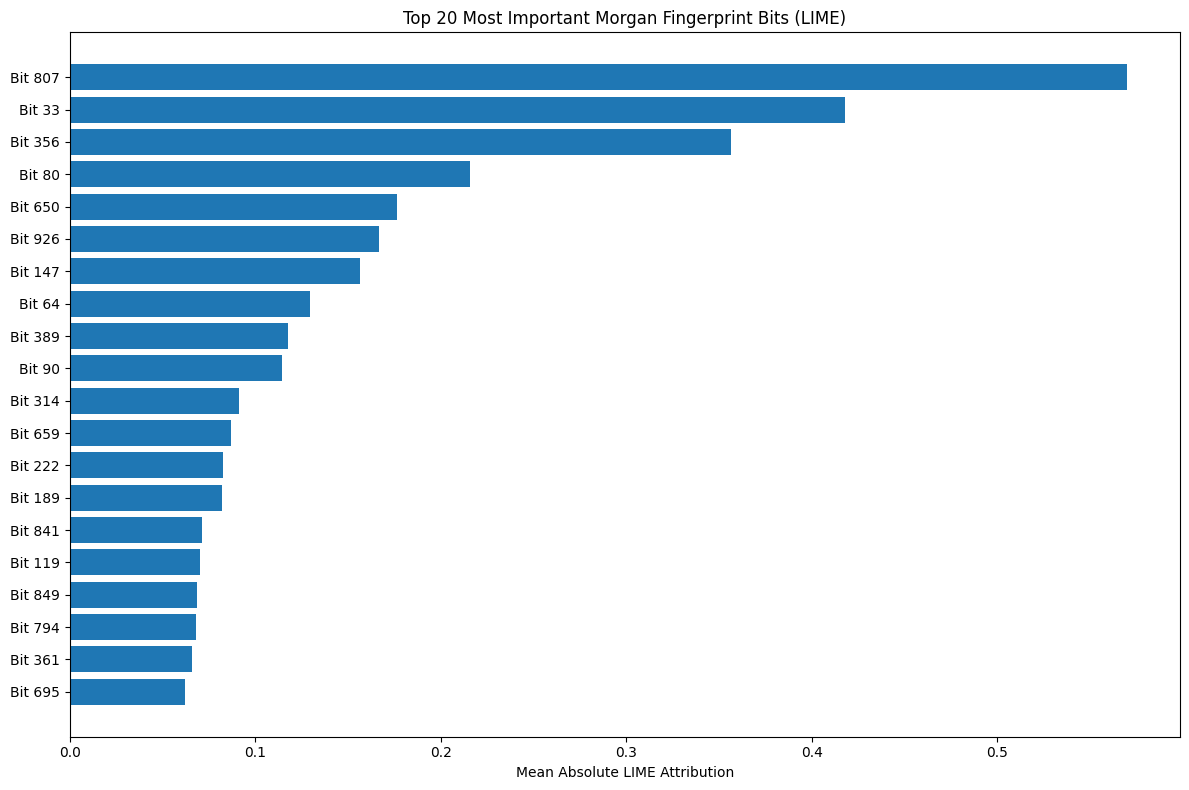

Top 5 most important bits: [807  33 356  80 650]
Their mean absolute attributions: [0.5698631  0.41785732 0.35648265 0.2158819  0.17662309]


In [22]:
# --- visualizing LIME explanations ---

# Analyze the most important bits across all samples
lime_attributions_np = lime_attributions.detach().numpy()

# Calculate mean absolute attribution for each bit
mean_abs_attributions = np.mean(np.abs(lime_attributions_np), axis=0)

# Find the top 20 most important bits
top_bits_indices = np.argsort(mean_abs_attributions)[-20:][::-1]
top_bits_scores = mean_abs_attributions[top_bits_indices]

# Create a bar plot showing the most important fingerprint bits
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_bits_indices)), top_bits_scores)
plt.yticks(range(len(top_bits_indices)), [f'Bit {i}' for i in top_bits_indices])
plt.xlabel('Mean Absolute LIME Attribution')
plt.title('Top 20 Most Important Morgan Fingerprint Bits (LIME)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top 5 most important bits: {top_bits_indices[:5]}")
print(f"Their mean absolute attributions: {top_bits_scores[:5]}")

Visualizing molecular patterns for top 5 most important LIME bits

Rank 1: Bit 807 (Mean Absolute Attribution: 0.5699)
  Pattern from: OCC1CCC(CO)O1
  Bit 807 molecular pattern:


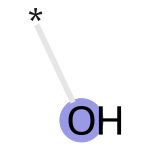

--------------------------------------------------

Rank 2: Bit 33 (Mean Absolute Attribution: 0.4179)
  Pattern from: CCCCC(=O)N(C)C1=CC=C(C=C1)[S](=O)(=O)N(C)C
  Bit 33 molecular pattern:


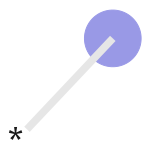

--------------------------------------------------

Rank 3: Bit 356 (Mean Absolute Attribution: 0.3565)
  Pattern from: O=C1CCC2CCCCC2O1
  Bit 356 molecular pattern:


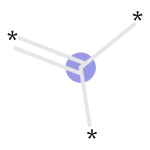

--------------------------------------------------

Rank 4: Bit 80 (Mean Absolute Attribution: 0.2159)
  Pattern from: OCC1CCC(CO)O1
  Bit 80 molecular pattern:


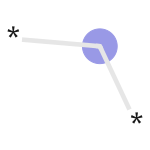

--------------------------------------------------

Rank 5: Bit 650 (Mean Absolute Attribution: 0.1766)
  Pattern from: O=C1CCC2CCCCC2O1
  Bit 650 molecular pattern:


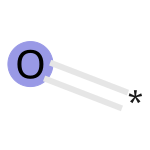

--------------------------------------------------


In [24]:
# --- visualizing molecular patterns for top LIME bits ---

# Find the top N most important bits from the LIME analysis
top_n = 5
top_bits_indices = np.argsort(mean_abs_attributions)[-top_n:][::-1]
top_bits_scores = mean_abs_attributions[top_bits_indices]

print(f"Visualizing molecular patterns for top {top_n} most important LIME bits")
print("="*70)

for rank, (bit_idx, score) in enumerate(zip(top_bits_indices, top_bits_scores), 1):
    print(f"\nRank {rank}: Bit {bit_idx} (Mean Absolute Attribution: {score:.4f})")
    
    # Find the first molecule with this bit active to use for visualization
    for i, mol_idx in enumerate(explain_indices):
        
        if explain_tensor[i][bit_idx] == 1:
            mol = data_frame.iloc[mol_idx]['mol']
            smiles = data_frame.iloc[mol_idx]['smiles']
            bit_info = fingerprint_generator.get_bit_info(mol)
            
            if bit_idx in bit_info:
                print(f"  Pattern from: {smiles}")
                print(f"  Bit {bit_idx} molecular pattern:")
                
                # Visualize the single bit pattern
                img = Draw.DrawMorganBit(mol, bit_idx, bit_info)
                display(img)
                break
    else:
        print(f"  ❌ No examples found for bit {bit_idx}")
    
    print("-" * 50)

Sample Analysis:
SMILES: O=C1CCC2CCCCC2O1
True solubility: -0.587
Predicted solubility: -1.554
Prediction error: 0.967
Number of active bits: 22


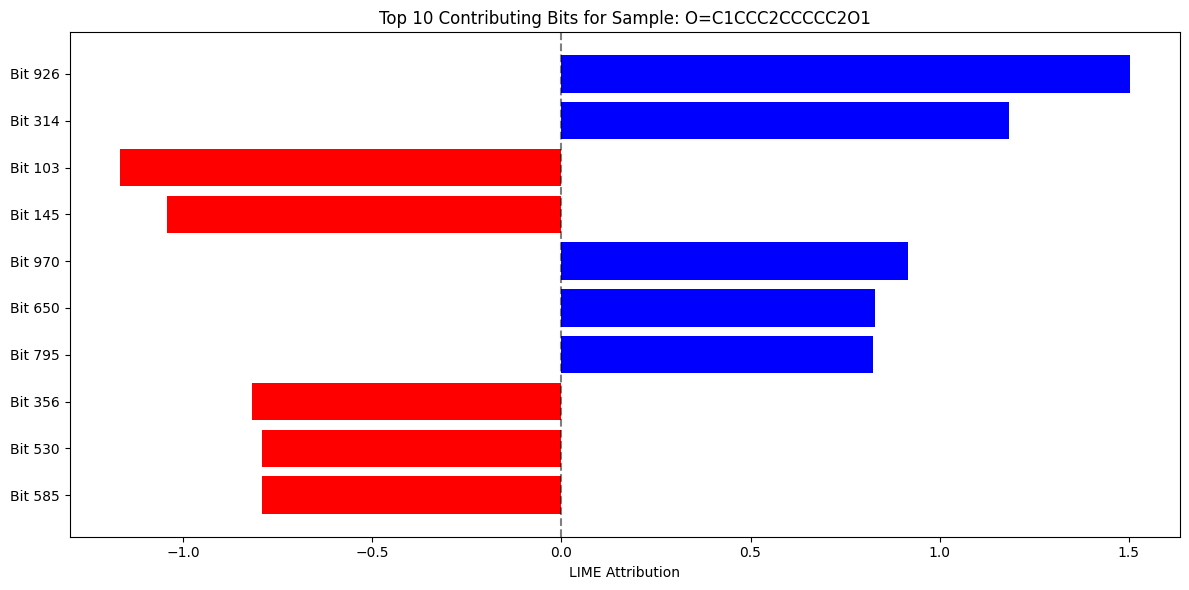


Top contributing bits (bit index: attribution):
  Bit 926: 1.5021 (increases solubility prediction)
  Bit 314: 1.1840 (increases solubility prediction)
  Bit 103: -1.1669 (decreases solubility prediction)
  Bit 145: -1.0416 (decreases solubility prediction)
  Bit 970: 0.9174 (increases solubility prediction)
  Bit 650: 0.8302 (increases solubility prediction)
  Bit 795: 0.8247 (increases solubility prediction)
  Bit 356: -0.8174 (decreases solubility prediction)
  Bit 530: -0.7924 (decreases solubility prediction)
  Bit 585: -0.7919 (decreases solubility prediction)


In [26]:
# --- individual sample explanation ---

# Select one sample for detailed analysis
sample_idx = 0
sample_molecule_idx = explain_indices[sample_idx]
sample_smiles = data_frame.iloc[sample_molecule_idx]['smiles']
sample_solubility = data_frame.iloc[sample_molecule_idx]['solubility']
sample_fingerprint = explain_tensor[sample_idx]
sample_attributions = lime_attributions[sample_idx]
sample_prediction = morgan_model(sample_fingerprint.unsqueeze(0)).item()

print(f"Sample Analysis:")
print(f"SMILES: {sample_smiles}")
print(f"True solubility: {sample_solubility:.3f}")
print(f"Predicted solubility: {sample_prediction:.3f}")
print(f"Prediction error: {abs(sample_solubility - sample_prediction):.3f}")

# Find active bits in this sample (bits that are set to 1)
active_bits = torch.where(sample_fingerprint == 1)[0].numpy()
print(f"Number of active bits: {len(active_bits)}")

# Get attributions for active bits only
active_attributions = sample_attributions[active_bits].detach().numpy()

# Find the most influential active bits for this sample
top_active_indices = np.argsort(np.abs(active_attributions))[-10:][::-1]
top_active_bits = active_bits[top_active_indices]
top_active_scores = active_attributions[top_active_indices]

# Visualize the top contributing bits for this individual sample
plt.figure(figsize=(12, 6))
colors = ['red' if score < 0 else 'blue' for score in top_active_scores]
plt.barh(range(len(top_active_bits)), top_active_scores, color=colors)
plt.yticks(range(len(top_active_bits)), [f'Bit {bit}' for bit in top_active_bits])
plt.xlabel('LIME Attribution')
plt.title(f'Top 10 Contributing Bits for Sample: {sample_smiles}')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop contributing bits (bit index: attribution):")
for bit, score in zip(top_active_bits, top_active_scores):
    direction = "increases" if score > 0 else "decreases"
    print(f"  Bit {bit}: {score:.4f} ({direction} solubility prediction)")**📊 LIME Attribution Plots.** The visualization above demonstrates LIME's local explanation approach. The first plot shows the fingerprint bits that are most consistently important across all analyzed molecules, providing a global view of structural features that influence solubility predictions. The second plot focuses on a single molecule, showing which specific bits contributed most to that individual prediction.

**Key Differences from SHAP.** Unlike SHAP values, which are guaranteed to sum to the difference between the prediction and the expected baseline value, LIME attributions represent the coefficients of a local linear model fitted around each instance. This means:

1. **Per-instance, aggregated differently**: both methods produce a separate attribution per instance, but SHAP values satisfy an additivity guarantee and are routinely aggregated across the dataset into a consistent *global* importance ranking (the SHAP bar plot); here LIME is applied purely locally, to individual molecules
2. **Discrete Perturbations**: For binary features like Morgan fingerprints, LIME naturally handles the discrete nature by turning bits on/off
3. **Interpretability**: Since Morgan fingerprints encode molecular substructures, each important bit corresponds to a specific structural pattern that influences solubility

The red bars in the individual sample plot indicate molecular features that decrease the predicted solubility (make the molecule less water-soluble), while blue bars indicate features that increase it. This provides direct insight into which structural patterns the model associates with higher or lower water solubility for that specific molecule. Note that this color convention differs from the SHAP beeswarm plot earlier: there, color encoded the *feature value* (red = high, blue = low), whereas here color encodes the *sign of the attribution* (red = decreases, blue = increases the prediction).**📊 LIME Attribution Plots.** The visualization above demonstrates LIME's local explanation approach. The first plot shows the fingerprint bits that are most consistently important across all analyzed molecules, providing a global view of structural features that influence solubility predictions. The second plot focuses on a single molecule, showing which specific bits contributed most to that individual prediction.

**Key Differences from SHAP.** Unlike SHAP values, which are guaranteed to sum to the difference between the prediction and the expected baseline value, LIME attributions represent the coefficients of a local linear model fitted around each instance. This means:

1. **Per-instance, aggregated differently**: both methods produce a separate attribution per instance, but SHAP values satisfy an additivity guarantee and are routinely aggregated across the dataset into a consistent *global* importance ranking (the SHAP bar plot); here LIME is applied purely locally, to individual molecules
2. **Discrete Perturbations**: For binary features like Morgan fingerprints, LIME naturally handles the discrete nature by turning bits on/off
3. **Interpretability**: Since Morgan fingerprints encode molecular substructures, each important bit corresponds to a specific structural pattern that influences solubility

The red bars in the individual sample plot indicate molecular features that decrease the predicted solubility (make the molecule less water-soluble), while blue bars indicate features that increase it. This provides direct insight into which structural patterns the model associates with higher or lower water solubility for that specific molecule. Note that this color convention differs from the SHAP beeswarm plot earlier: there, color encoded the *feature value* (red = high, blue = low), whereas here color encodes the *sign of the attribution* (red = decreases, blue = increases the prediction).


🧬 Complete Molecular Analysis for Sample: O=C1CCC2CCCCC2O1

📍 Full Molecule Structure:
SMILES: O=C1CCC2CCCCC2O1
True solubility: -0.587
Predicted solubility: -1.554


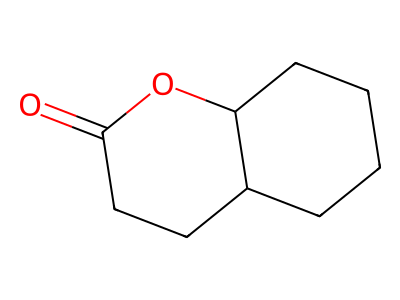


🔍 Top 3 Most Impactful Molecular Patterns:
------------------------------------------------------------

Rank 1: Bit 926
  Attribution: 1.5021 (increases solubility prediction)
  ✅ Pattern found - highlighting molecular fragment
  Individual pattern for Bit 926:


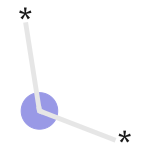


Rank 2: Bit 314
  Attribution: 1.1840 (increases solubility prediction)
  ✅ Pattern found - highlighting molecular fragment
  Individual pattern for Bit 314:


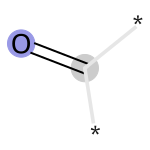


Rank 3: Bit 103
  Attribution: -1.1669 (decreases solubility prediction)
  ✅ Pattern found - highlighting molecular fragment
  Individual pattern for Bit 103:


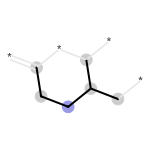


🎨 Combined View - All Top 3 Patterns Together:
This visualization shows how the three most important molecular
fragments work together to influence the solubility prediction.


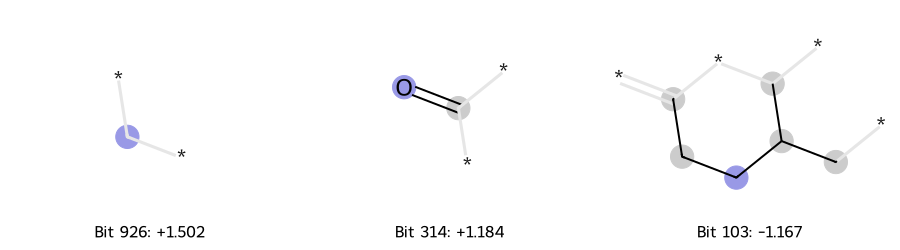


📊 Summary of Top 3 Contributions:
  1. Bit 926: +1.5021 (39.0% of total, ↗️ increases prediction)
  2. Bit 314: +1.1840 (30.7% of total, ↗️ increases prediction)
  3. Bit 103: -1.1669 (30.3% of total, ↘️ decreases prediction)



In [28]:
# --- comprehensive molecular visualization with top 3 bits ---

print(f"\n🧬 Complete Molecular Analysis for Sample: {sample_smiles}")
print("="*80)

# Get the top 3 most impactful bits for this specific sample
top_3_bits = top_active_bits[:3]
top_3_scores = top_active_scores[:3]

# First, display the full molecule structure
print(f"\n📍 Full Molecule Structure:")
print(f"SMILES: {sample_smiles}")
print(f"True solubility: {sample_solubility:.3f}")
print(f"Predicted solubility: {sample_prediction:.3f}")

mol = data_frame.iloc[sample_molecule_idx]['mol']
bit_info = fingerprint_generator.get_bit_info(mol)

# Display the full molecule without any highlighting
img_full = Draw.MolToImage(mol, size=(400, 300))
display(img_full)

print(f"\n🔍 Top 3 Most Impactful Molecular Patterns:")
print("-" * 60)

# Create a combined visualization showing the molecule with all top 3 bits highlighted
combined_examples = []
individual_scores = []

for rank, (bit_idx, score) in enumerate(zip(top_3_bits, top_3_scores), 1):
    direction = "increases" if score > 0 else "decreases"
    print(f"\nRank {rank}: Bit {bit_idx}")
    print(f"  Attribution: {score:.4f} ({direction} solubility prediction)")
    
    if bit_idx in bit_info:
        print(f"  ✅ Pattern found - highlighting molecular fragment")
        combined_examples.append((mol, bit_idx, bit_info))
        individual_scores.append(f"Bit {bit_idx}: {score:+.3f}")
        
        # Individual visualization for each bit
        print(f"  Individual pattern for Bit {bit_idx}:")
        img_individual = Draw.DrawMorganBit(mol, bit_idx, bit_info)
        display(img_individual)
    else:
        print(f"  ❌ Pattern not found in bit info")

# Combined visualization showing all top 3 bits together
if combined_examples:
    print(f"\n🎨 Combined View - All Top 3 Patterns Together:")
    print("This visualization shows how the three most important molecular")
    print("fragments work together to influence the solubility prediction.")
    
    # Create labels with both bit index and attribution score
    combined_labels = individual_scores
    
    img_combined = Draw.DrawMorganBits(
        combined_examples, 
        molsPerRow=3, 
        legends=combined_labels,
        subImgSize=(300, 250)
    )
    display(img_combined)
    
    print(f"\n📊 Summary of Top 3 Contributions:")
    total_abs_contribution = sum(abs(score) for score in top_3_scores)
    for i, (bit_idx, score) in enumerate(zip(top_3_bits, top_3_scores), 1):
        contribution_percent = (abs(score) / total_abs_contribution) * 100
        direction = "↗️ increases" if score > 0 else "↘️ decreases"
        print(f"  {i}. Bit {bit_idx}: {score:+.4f} ({contribution_percent:.1f}% of total, {direction} prediction)")

else:
    print("❌ No visualizable patterns found for the top contributing bits")
    
print("\n" + "="*80)

**🔬 Molecular Pattern Analysis.** The visualization above reveals the actual molecular substructures that correspond to the most important fingerprint bits identified by LIME. Each highlighted molecular fragment represents a structural pattern that the model has learned to associate with changes in water solubility predictions.

**Key Insights:**
- **Highlighted atoms** show the substructure encoded by each bit: the **blue** atom is the central atom of the circular environment, **yellow** marks aromatic atoms, and **grey** marks the remaining atoms within the bit's radius; the `*` symbols mark the attachment points where the fragment connects to the rest of the molecule
- **Rank ordering** indicates which structural patterns are most consistently influential across different molecules
- **Multiple examples** demonstrate how the same bit can capture similar substructures across different molecular contexts
- **Chemical interpretability** allows domain experts to validate whether the model is focusing on chemically meaningful patterns

This analysis bridges the gap between abstract feature attributions and concrete chemical knowledge, enabling researchers to understand not just *which* features are important, but *what* those features represent in terms of actual molecular structure. This is crucial for building trust in the model's predictions and for gaining new insights into structure-activity relationships.

**📊 LIME Attribution Plots.** The visualization above demonstrates LIME's local explanation approach. The first plot shows the fingerprint bits that are most consistently important across all analyzed molecules, providing a global view of structural features that influence solubility predictions. The second plot focuses on a single molecule, showing which specific bits contributed most to that individual prediction.

**Key Differences from SHAP.** Unlike SHAP values, which are guaranteed to sum to the difference between the prediction and the expected baseline value, LIME attributions represent the coefficients of a local linear model fitted around each instance. This means:

1. **Per-instance, aggregated differently**: both methods produce a separate attribution per instance, but SHAP values satisfy an additivity guarantee and are routinely aggregated across the dataset into a consistent *global* importance ranking (the SHAP bar plot); here LIME is applied purely locally, to individual molecules
2. **Discrete Perturbations**: For binary features like Morgan fingerprints, LIME naturally handles the discrete nature by turning bits on/off
3. **Interpretability**: Since Morgan fingerprints encode molecular substructures, each important bit corresponds to a specific structural pattern that influences solubility

The red bars in the individual sample plot indicate molecular features that decrease the predicted solubility (make the molecule less water-soluble), while blue bars indicate features that increase it. This provides direct insight into which structural patterns the model associates with higher or lower water solubility for that specific molecule. Note that this color convention differs from the SHAP beeswarm plot earlier: there, color encoded the *feature value* (red = high, blue = low), whereas here color encodes the *sign of the attribution* (red = decreases, blue = increases the prediction).

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 1.4** $\cdot$ Modify the Morgan fingerprint generator to use a different radius (e.g., radius=3) and retrain the model. Compare the LIME explanations from the new model with those from the radius=2 model. What differences do you observe in terms of which bits are deemed most important?

</div>

## **1.4** $\cdot$ 🔬 Discussion and Limitations

The feature-attribution methods presented in this tutorial provide valuable insights into how machine learning models prioritize different molecular properties when making predictions. However, several important limitations should be considered when interpreting these explanations.

**Chemical Validity of Perturbations.** Both SHAP and LIME generate explanations by perturbing the input features and observing how predictions change. For SHAP, this involves replacing feature values with samples drawn from a background distribution &mdash; effectively asking "what would the model predict if this molecule had the ClogP of molecule A but the molecular weight of molecule B?" For LIME, perturbations involve toggling fingerprint bits on or off to create modified input vectors. In both cases, the perturbed inputs may not correspond to chemically valid or synthesizable molecules. A descriptor vector combining properties from multiple unrelated compounds, or a fingerprint with an arbitrary subset of bits activated, may represent a point in feature space that no real molecule could occupy. The explanations therefore reflect model behavior on potentially unrealistic inputs, and care should be taken when drawing conclusions about actual structure-property relationships.

**Loss of Structural Context.** By representing molecules as fixed-length descriptor vectors or fingerprints, structural information is necessarily compressed and abstracted. Two structurally distinct molecules may yield identical or very similar descriptor vectors, and fingerprint hash collisions can cause different substructures to map to the same bit index. More fundamentally, the spatial arrangement of functional groups &mdash; which often determines molecular properties &mdash; is largely lost in these representations. A hydroxyl group adjacent to an electron-withdrawing group behaves differently than one in isolation, but this contextual information may not be captured by the features. The explanations generated by SHAP and LIME operate at the level of these abstract features rather than the molecular graph itself, which limits the structural specificity of the insights they can provide. Structure-attribution methods, as introduced in the following tutorial, address this limitation by operating directly on molecular graphs.

**Reproducibility.** Several sources of randomness affect the explanations generated in this tutorial. The train-test split, the selection of background data for SHAP, and the perturbation sampling in LIME all involve stochastic elements. As a consequence, re-running the notebook may produce quantitatively different results &mdash; feature importance rankings may shift, and the specific SHAP values or LIME attributions for individual molecules will vary. For reproducible analyses, random seeds should be fixed at the beginning of the workflow. When reporting results, it may also be advisable to average explanations over multiple runs or to report confidence intervals, particularly for LIME where the local surrogate model is fitted on a relatively small number of perturbed samples.

## **References**

**Datasets**

- Sorkun, M. C., Khetan, A., & Er, S. (2019). AqSolDB, a curated reference set of aqueous solubility and 2D descriptors for a diverse set of compounds. *Scientific Data*, 6, 143. https://doi.org/10.1038/s41597-019-0151-1

**Methods**

- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In *Advances in Neural Information Processing Systems* (NeurIPS), 30, 4766–4777. https://arxiv.org/abs/1705.07874 | [GitHub](https://github.com/shap/shap)

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1135–1144. https://doi.org/10.1145/2939672.2939778

- Rogers, D., & Hahn, M. (2010). Extended-connectivity fingerprints. *Journal of Chemical Information and Modeling*, 50(5), 742–754. https://doi.org/10.1021/ci100050t

- Shapley, L. S. (1953). A value for n-person games. In H. W. Kuhn & A. W. Tucker (Eds.), *Contributions to the Theory of Games II*, Annals of Mathematics Studies, 28, 307–317. Princeton University Press.

**Software**

- Landrum, G. et al. (2024). RDKit: Open-source cheminformatics software. https://www.rdkit.org

- Kokhlikyan, N., Miglani, V., Martin, M., Wang, E., Alsallakh, B., Reynolds, J., Melnikov, A., Kliushkina, N., Araya, C., Yan, S., & Reblitz-Richardson, O. (2020). Captum: A unified and generic model interpretability library for PyTorch. https://arxiv.org/abs/2009.07896 | [GitHub](https://github.com/pytorch/captum)

- Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E. Z., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., Bai, J., & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. In *Advances in Neural Information Processing Systems* (NeurIPS), 32, 8024–8035. https://arxiv.org/abs/1912.01703